# **Import需要用的模組**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats
import statsmodels.api as sm

# **讀取資料**

In [15]:
df_robot = pd.read_csv('/Users/huangshifeng/Desktop/ML_Learning_Curve/Robot_Cohort.csv')
df_lap = pd.read_csv('/Users/huangshifeng/Desktop/ML_Learning_Curve/Lap_Cohort.csv')

df_robot['approach'] = 1   # 1 = robot
df_lap['approach']   = 0   # 0 = lap

df_clean = pd.concat([df_robot, df_lap], axis=0, ignore_index=True)
df_clean = df_clean.replace('.', np.nan)

### 粗略看大致的df資訊

In [16]:
print(df_clean.shape)
print(df_clean['approach'].value_counts())
print(df_clean.info())

(304, 26)
approach
0    211
1     93
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               304 non-null    int64  
 1   Gender                   304 non-null    int64  
 2   OP_Year                  304 non-null    int64  
 3   Age                      304 non-null    float64
 4   BMI                      304 non-null    float64
 5   ASA                      304 non-null    int64  
 6   Procedure_1              304 non-null    int64  
 7   Protective_Stoma         304 non-null    int64  
 8   Procedure_Time(min)      304 non-null    int64  
 9   Blood_Loss               304 non-null    int64  
 10  Conv_to_Open             304 non-null    int64  
 11  Time_1stFlatus(d)        303 non-null    object 
 12  LengthStay               303 non-null    object 
 13  Major_Complicatio

### 先定義變項類別

In [5]:
ord_features=[]
nom_features=['Procedure_1']
bin_features=['Protective_Stoma', 'Gender', 'Conv_to_Open', 'Major_Complications', 'Anastomotic_Leakage', 'Unplanned_ICU_Admission', 'Mortality_30days', 'Neoadjuvant', 'Composite_Adverse_Event', 'Is_Rectum', 'CRM_positivity', 'approach']
num_features=['ASA', 'Procedure_Time(min)', 'Blood_Loss', 'Time_1stFlatus(d)', 'LengthStay', 'From_Anal_Verge(cm)', 'Tumor_Size(cm)', 'Distal_Margin(cm)', 'No_LNs']

#### 看各變項dtypes

In [44]:
df_clean.dtypes

Patient_ID                    int64
Gender                        int64
OP_Year                       int64
Age                         float64
BMI                         float64
ASA                        category
Procedure_1                   int64
Protective_Stoma              int64
Procedure_Time(min)           int64
Blood_Loss                    int64
Conv_to_Open                  int64
Time_1stFlatus(d)             Int64
LengthStay                    Int64
Major_Complications           int64
Anastomotic_Leakage           int64
Unplanned_ICU_Admission       int64
Mortality_30days              int64
Neoadjuvant                   int64
Composite_Adverse_Event       int64
Is_Rectum                     int64
From_Anal_Verge(cm)         float64
Tumor_Size(cm)              float64
Distal_Margin(cm)           float64
CRM_positivity                Int64
No_LNs                        int64
approach                      int64
dtype: object

#### Check為什麼object欄位是object

In [23]:
df_clean['Time_1stFlatus(d)'].value_counts(dropna=False) #看有哪些奇怪的值

1


#### 原本的是數值的欄位卻變成object，需要先pd.to_numeric再astype，如果直接astype會報錯

In [32]:
df_clean['Time_1stFlatus(d)']=pd.to_numeric(df_clean['Time_1stFlatus(d)'], errors='coerce')
df_clean['Time_1stFlatus(d)'].value_counts(dropna=False)
df_clean['Time_1stFlatus(d)']=df_clean['Time_1stFlatus(d)'].astype('Int64')
df_clean.dtypes

Patient_ID                   int64
Gender                       int64
OP_Year                      int64
Age                        float64
BMI                        float64
ASA                          int64
Procedure_1                  int64
Protective_Stoma             int64
Procedure_Time(min)          int64
Blood_Loss                   int64
Conv_to_Open                 int64
Time_1stFlatus(d)            Int64
LengthStay                  object
Major_Complications          int64
Anastomotic_Leakage          int64
Unplanned_ICU_Admission      int64
Mortality_30days             int64
Neoadjuvant                  int64
Composite_Adverse_Event      int64
Is_Rectum                    int64
From_Anal_Verge(cm)        float64
Tumor_Size(cm)             float64
Distal_Margin(cm)          float64
CRM_positivity             float64
No_LNs                       int64
approach                     int64
dtype: object

In [34]:
df_clean['LengthStay'].value_counts(dropna=False)
df_clean['LengthStay']=pd.to_numeric(df_clean['LengthStay'], errors='coerce')
df_clean['LengthStay']=df_clean['LengthStay'].astype('Int64')
df_clean['LengthStay'].dtype

Int64Dtype()

In [41]:
df_clean['CRM_positivity']=df_clean['CRM_positivity'].astype('Int64') #Float轉整數

#### 這裡示範Ordinal Categoricals怎麼處理

In [35]:
from pandas.api.types import CategoricalDtype
ASA_type = CategoricalDtype(categories=[1, 2, 3, 4], ordered=True)
df_clean['ASA'] = df_clean['ASA'].astype(ASA_type)

#### 看一下缺失值資訊

In [39]:
na_counts=df_clean.isna().sum()
na_ratio=df_clean.isna().mean()
print(na_ratio)
print(na_counts)

Patient_ID                 0.000000
Gender                     0.000000
OP_Year                    0.000000
Age                        0.000000
BMI                        0.000000
ASA                        0.000000
Procedure_1                0.000000
Protective_Stoma           0.000000
Procedure_Time(min)        0.000000
Blood_Loss                 0.000000
Conv_to_Open               0.000000
Time_1stFlatus(d)          0.003289
LengthStay                 0.003289
Major_Complications        0.000000
Anastomotic_Leakage        0.000000
Unplanned_ICU_Admission    0.000000
Mortality_30days           0.000000
Neoadjuvant                0.000000
Composite_Adverse_Event    0.000000
Is_Rectum                  0.000000
From_Anal_Verge(cm)        0.134868
Tumor_Size(cm)             0.069079
Distal_Margin(cm)          0.003289
CRM_positivity             0.009868
No_LNs                     0.000000
approach                   0.000000
dtype: float64
Patient_ID                  0
Gender             

#### 看看最終成果

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Patient_ID               304 non-null    int64   
 1   Gender                   304 non-null    int64   
 2   OP_Year                  304 non-null    int64   
 3   Age                      304 non-null    float64 
 4   BMI                      304 non-null    float64 
 5   ASA                      304 non-null    category
 6   Procedure_1              304 non-null    int64   
 7   Protective_Stoma         304 non-null    int64   
 8   Procedure_Time(min)      304 non-null    int64   
 9   Blood_Loss               304 non-null    int64   
 10  Conv_to_Open             304 non-null    int64   
 11  Time_1stFlatus(d)        303 non-null    Int64   
 12  LengthStay               303 non-null    Int64   
 13  Major_Complications      304 non-null    int64   
 14  Anastomoti

#### 輸出成parquet檔案

In [59]:
df_clean.to_parquet("/Users/huangshifeng/Desktop/ML_Learning_Curve/data_typed.parquet", index=False, engine='pyarrow')

#### 同場加映：視覺化

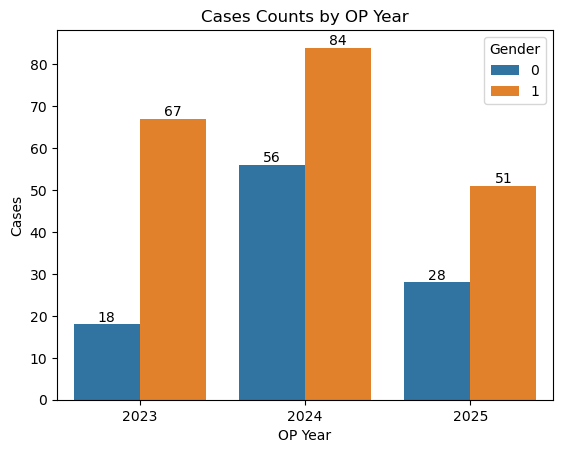

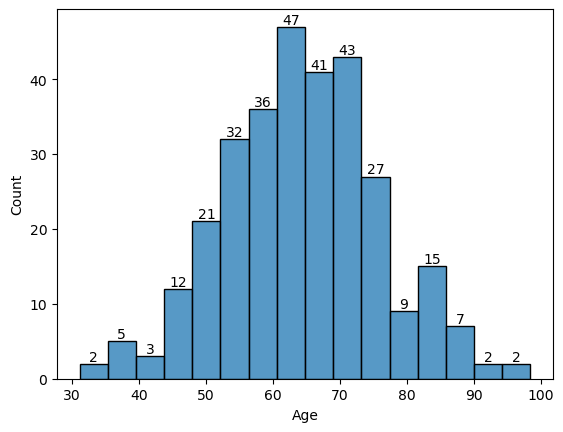

In [57]:
#Countplot
g=sns.countplot(x='OP_Year', hue='Gender', data=df_clean)
g.set_title('Cases Counts by OP Year')
g.set(xlabel='OP Year', ylabel='Cases')
g.bar_label(g.containers[0]) #標出Counts
g.bar_label(g.containers[1])
plt.show()

#Histogram
g=sns.histplot(x='Age', data=df_clean)
g.bar_label(g.containers[0])
plt.show()